# Robo2VLM-1 — Minimal Usage Notebook

**Dataset**: Robo2VLM-1  
**Paper**: *Robo2VLM: Visual Question Answering from Large-Scale In-the-Wild Robot Manipulation Datasets* (Chen et al., 2025)  
**HF**: https://huggingface.co/datasets/keplerccc/Robo2VLM-1

Goal: **open → inspect → visualize → evaluate a VLM (e.g., Qwen-VL-3B)**  
No training, only inspection + inference-style eval.

## 1. Setup (lightweight, no GPU required)


# venv: mm_data_venv
pip install pandas pyarrow pillow datasets transformers accelerate

## 2. Locate Parquet shards
Here, we are only using their test splits. You can download them along train splits from here:
https://huggingface.co/datasets/keplerccc/Robo2VLM-1/tree/main/data

In [1]:
import glob
files = sorted(glob.glob("test-*.parquet"))
files

['test-00000-of-00003.parquet',
 'test-00001-of-00003.parquet',
 'test-00002-of-00003.parquet']

## 3. Inspect schema (what’s inside)

In [2]:
import pyarrow.parquet as pq
pq.read_table(files[0]).schema

id: string
question: string
choices: string
correct_answer: int64
image: struct<bytes: binary, path: string>
  child 0, bytes: binary
  child 1, path: string
-- schema metadata --
huggingface: '{"info": {"features": {"id": {"dtype": "string", "_type": "' + 196

## 4. Load a shard and preview rows

In [3]:
import pandas as pd
df = pd.read_parquet(files[0])
df.head()

,id,question,choices,correct_answer,image
0,fractal20220817_data_place_blue_plastic_bottle...,Is there any obstacle blocking the robot from ...,"['No', 'Cannot be determined', 'Partially reac...",0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
1,fractal20220817_data_place_blue_plastic_bottle...,The robot is to place blue plastic bottle into...,"['Cannot be determined', 'No', 'Yes', 'Task wa...",1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
2,fractal20220817_data_place_blue_plastic_bottle...,Is there any obstacle blocking the robot from ...,"['Yes', 'Partially reachable', 'No', 'Cannot b...",2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
3,fractal20220817_data_place_blue_plastic_bottle...,The robot is to place blue plastic bottle into...,"['Yes', 'Task was not attempted', 'Cannot be d...",3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
4,fractal20220817_data_place_blue_plastic_bottle...,Is there any obstacle blocking the robot from ...,"['Partially reachable', 'Yes', 'No', 'Cannot b...",2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...


## 5. Visualize an example

In [4]:
from PIL import Image
import io, ast

row = df.iloc[1]

img = Image.open(io.BytesIO(row["image"]["bytes"]))
choices = ast.literal_eval(row["choices"])
answer = choices[row["correct_answer"]]

img, row["question"], choices, answer

(<PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x256>,
 'The robot is to place blue plastic bottle into middle drawer. Has the robot successfully completed the task?',
 ['Cannot be determined', 'No', 'Yes', 'Task was not attempted'],
 'No')

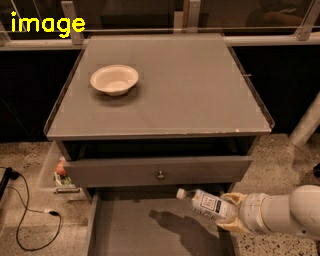

In [5]:
img

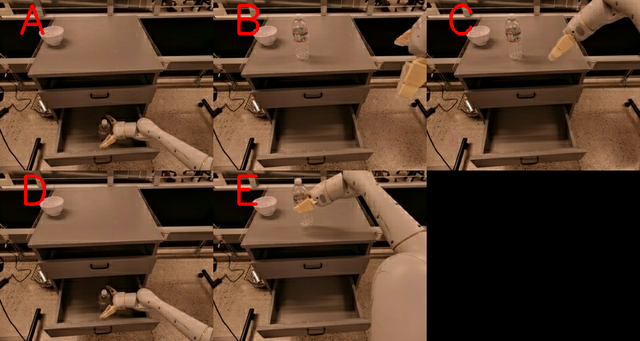

In [6]:
from PIL import Image
import io

row = df.iloc[1030]
img_bytes = row["image"]["bytes"]
img = Image.open(io.BytesIO(img_bytes))
img

In [7]:
import ast

choices = ast.literal_eval(row["choices"])
answer = choices[row["correct_answer"]]
choices, answer

(['Configuration A',
  'Configuration B',
  'Configuration E',
  'Configuration C',
  'Configuration D'],
 'Configuration A')

## 6. Load via Hugging Face `datasets` (semantic features)

In [8]:
from datasets import load_dataset

ds = load_dataset("parquet", data_files={"test": files})
ds["test"].features


e:\1_Codes\Multimodal_Datasets_Generative_Reasoning\mm_data_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'id': Value('string'),
 'question': Value('string'),
 'choices': Value('string'),
 'correct_answer': Value('int64'),
 'image': Image(mode=None, decode=True)}

## 7. Prepare VQA inputs for VLM evaluation

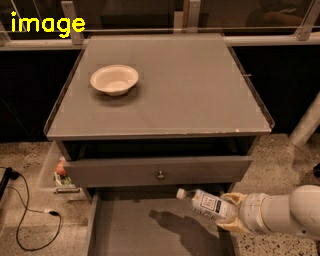

In [9]:
sample = ds["test"][1]

prompt = f"""
Question: {sample['question']}
Choices:
{chr(10).join([f"{i}. {c}" for i, c in enumerate(sample['choices'])])}
Answer with the choice index.
"""

image = sample["image"]  # PIL Image
prompt
image

## 8. Run inference with a VLM (example: Qwen-VL-3B)

In [ ]:
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype="auto",
    device_map="auto",
    trust_remote_code=True,
)

import ast

sample = ds["test"][0]

image = sample["image"]

# FIX HERE
choices = sample["choices"]
if isinstance(choices, str):
    choices = ast.literal_eval(choices)

question = sample["question"]

prompt = f"""Question: {question}
Choices:
""" + "\n".join([f"{i}. {c}" for i,c in enumerate(choices)]) + "\nAnswer with the choice index."

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

inputs = processor(
    text=[text],
    images=[image],
    return_tensors="pt",
    padding=True,
)

inputs = {k: v.to(model.device) if hasattr(v, "to") else v for k, v in inputs.items()}

with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=20)

pred = processor.batch_decode(out, skip_special_tokens=True)[0]
print(pred)


Loading weights: 100%|██████████| 824/824 [00:00<00:00, 24807.86it/s]
Some parameters are on the meta device because they were offloaded to the cpu and disk.


system
You are a helpful assistant.
user
Question: Is there any obstacle blocking the robot from reaching bottle?
Choices:
0. No
1. Cannot be determined
2. Partially reachable
3. Yes
Answer with the choice index.
assistant
0


In [21]:
import ast, re

N = 20   # number of samples to evaluate
correct = 0

for i in range(N):

    sample = ds["test"][i]
    image = sample["image"]

    choices = sample["choices"]
    if isinstance(choices, str):
        choices = ast.literal_eval(choices)

    question = sample["question"]

    prompt = f"""Question: {question}
Choices:
""" + "\n".join([f"{i}. {c}" for i,c in enumerate(choices)]) + "\nAnswer with the choice index."

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(text=[text], images=[image], return_tensors="pt", padding=True)
    inputs = {k: v.to(model.device) if hasattr(v, "to") else v for k,v in inputs.items()}

    out = model.generate(**inputs, max_new_tokens=20)
    pred = processor.batch_decode(out, skip_special_tokens=True)[0]

    pred_idx = int(re.findall(r"\d+", pred)[-1])
    gt_idx = sample["correct_answer"]

    if pred_idx == gt_idx:
        correct += 1

    print(f"\nSample {i}")
    print("pred:", pred_idx, "| gt:", gt_idx)
    print("pred answer:", choices[pred_idx])
    print("gt answer:", choices[gt_idx])

accuracy = correct / N
print("\nFinal accuracy:", accuracy)


Sample 0
pred: 1 | gt: 0
pred answer: Cannot be determined
gt answer: No

Sample 1
pred: 2 | gt: 1
pred answer: Yes
gt answer: No

Sample 2
pred: 2 | gt: 2
pred answer: No
gt answer: No

Sample 3
pred: 3 | gt: 3
pred answer: No
gt answer: No

Sample 4
pred: 2 | gt: 2
pred answer: No
gt answer: No

Sample 5
pred: 1 | gt: 2
pred answer: Cannot be determined
gt answer: No

Sample 6
pred: 4 | gt: 1
pred answer: Approaching the bottle with open gripper
gt answer: Firmly grasping the bottle

Sample 7
pred: 3 | gt: 3
pred answer: No
gt answer: No

Sample 8
pred: 3 | gt: 3
pred answer: Moving away with open gripper after releasing the bottle
gt answer: Moving away with open gripper after releasing the bottle

Sample 9
pred: 1 | gt: 3
pred answer: Configuration C
gt answer: None of the above

Sample 10
pred: 2 | gt: 4
pred answer: Configuration E
gt answer: Configuration A

Sample 11
pred: 4 | gt: 3
pred answer: Firmly grasping the sponge
gt answer: None of the above

Sample 12
pred: 3 | gt: 1

## 9. Simple evaluation loop (accuracy)

In [ ]:
def eval_one(sample):
    prompt = f"Question: {sample['question']}\nChoices:\n" + \
             "\n".join([f"{i}. {c}" for i, c in enumerate(sample['choices'])]) + \
             "\nAnswer with the choice index."

    inputs = processor(images=sample["image"], text=prompt, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=10)
    pred = processor.decode(out[0], skip_special_tokens=True)

    return str(sample["correct_answer"]) in pred

sum(eval_one(ds["test"][i]) for i in range(20)) / 20

## 10. What Robo2VLM-1 is good for (VLM eval)

## Citation

## Dataset

This notebook uses **Robo2VLM-1**, a large-scale visual question answering dataset
derived from real-world robot manipulation trajectories.

**Dataset citation**

```bibtex
@misc{chen2025robo2vlmvisualquestionanswering,
  title={Robo2VLM: Visual Question Answering from Large-Scale In-the-Wild Robot Manipulation Datasets},
  author={Chen, Kaiyuan and Xie, Shuangyu and Ma, Zehan and Goldberg, Ken},
  year={2025},
  eprint={2505.15517},
  archivePrefix={arXiv},
  primaryClass={cs.RO}
}
```

Code for loading, inspecting, visualizing, and evaluating the Robo2VLM-1 dataset
was written by **Masoud Jafaripour** for analysis and VLM evaluation purposes.
This code is **not affiliated with the dataset authors**.